In [ ]:
!pip uninstall transformers -y
!pip install transformers==4.48.2

## Definizione dell'instruction e della relativa answer

Dovendo addestrare un modello di tipo decoder-only e avendo utilizzato il template già implementato chat-template, abbiamo definito l'instruction dove diamo delle direttive al modello. 

In particolare, abbiamo definito il tipo di task che il modello dovrà compiere dando anche delle direttive precise su come dovrà essere formata la risposta. 

Il modello dovrà classificare il tweet passato in input in una delle quattro categorie previste dal task: anger, joy, optimism e sadness. 

Inoltre, per guidare il modello nella risposta, abbiamo definito la stringa answer dopo la quale il modello dovrà inserire la sua risposta e quindi la classificazione effettiva del tweet. Questa stringa verrà, quindi, utilizzata nella modifica del dataset permettendoci di realizzare un prompt che spinga il modello nell'esecuzione del task di classificazione.

In [3]:
instruction = "Classify the following tweet in one of the following categories: anger, joy, optimism or sadness. Respond with only one word."
answer = "I would classify the tweet as: "

## Import delle principali librerie e caricamento del modello e del tokenizer

Nel blocco sottostante importiamo le librerie necessarie per il recupero del modello.
Dopo aver definito la chiave di autenticazione, effettuato il login e definito il nome del modello che verrà utilizzato per questo task di classificazione, tramite la classe AutoModelForCausalLM effettuiamo il download del modello preaddestrato per poi eseguire un finetuning sul nostro dataset e quindi modificare i parametri del modello facendo sì che il modello si specializzi nel task di riconoscimento delle emozioni

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import login

model_name = 'meta-llama/Llama-3.2-1B-Instruct'

chiave_di_autenticazione = "key"

login(token=chiave_di_autenticazione)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

## Data Augmentation

Analizzando il dataset è emerso uno sbilanciamento tra le quattro classi. Abbiamo quindi deciso di concentrarci sul loro bilanciamento tramite procedure di Data Augmentation. In particolare abbiamo deciso di procedere con l'utilizzo di un modello LLama che ci permettesse di fornire in input un tweet e ottenere in uscita una sua parafrsi. In questo modo riusciamo a mantenere il significato generale della frase, non andando ad alterare il tipo di emozione presente nella stessa. Quindi siamo riusciti ad ottenere nuovi dati, e quindi a bilanciare (il più possibile) il dataset, per garantire un addestramento migliore del modello.

Tramite la funzione DataAugmentation() iteriamo le classi e individuiamo quelle il cui numero di campioni è inferiore ad un valore soglia max_sample, in questo caso impostato a 800. Nel caso in cui la classe attuale non dovesse rispettare il vincolo imposto, scegliamo in modo randomico un tweet e tramite la funzione generate_tweet_with_llama() generiamo un nuovo tweet tramite la sua parafrasi. Ottenuta la parafrasi, la label e il nuovo tweet vengono inseriti nelle rispettive liste nella stessa posizione ottenuta in modo randomico.

Per quanto riguarda la funzione generate_tweet_with_llama, questa prende in input, oltre al tweet e alla label, anche i parametri relativi al sample del decoder. In particolare i parametri passati sono temperature e top_p. Il valore di temperature è stato impostato a 0.7 per garantire creatività nella generazione delle parafrasi. top_p, invece, limita la scelta alle parole più rilevanti basate sulla probabilità cumulativa.

All'interno della funzione definiamo, quindi, un prompt che implementa il few shot, in questo caso 2-shot, per guidare il modello alla generazione corretta delle parafrasi.

Infine, fornendo i parametri appena discussi al modello, otteniamo il tweet parafrasato che verrà poi restituito dalla funzione

In [ ]:
import random
import copy
import torch

def generate_tweet_with_llama(model, tokenizer, label, example_tweet, max_new_tokens=30, temperature=0.7, top_p=0.9):

    prompt = f"""
    Paraphrase the following tweet in a different way, while keeping the same meaning and tone. The paraphrased tweet should be similar in meaning but use different words or sentence structure.
    
    Original tweet: "I woke up late, rushed to get ready, and then I missed my bus. What a day!" 
    Paraphrased tweet: "I slept in, hurried through my morning routine, and ended up missing my bus. My day isn't off to a good start!"
    
    Original tweet: "My alarm clock was ringing this morning, and my flatmate knocked on my door and asked if I set anything on fire or if I'm burning alive :) :)"
    Paraphrased tweet: "I woke up to my alarm blaring and my flatmate knocking on my door, asking if I’d set something on fire or if I was dying :) :)"
    
    Original tweet: "{example_tweet}"
    Paraphrased tweet:
    """

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, padding=True)
    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=top_p,
            num_return_sequences=1
        )

    generated_text = tokenizer.decode(output[0], skip_special_tokens=True).strip()

    paraphrased_tweet = generated_text.split("Paraphrased tweet:")[-1].strip()  
    start_idx = paraphrased_tweet.find('"') + 1
    end_idx = paraphrased_tweet.find('"', start_idx)

    if start_idx != -1 and end_idx != -1:
        paraphrased_tweet = paraphrased_tweet[start_idx:end_idx]
    else:
        paraphrased_tweet = paraphrased_tweet

    return paraphrased_tweet

def dataAugumentation(train_x, train_y):
    i = 0
    class_counts = {label: train_y.count(label) for label in set(train_y)}
    max_samples = 800
    
    new_train_x = copy.deepcopy(train_x)
    new_train_y = copy.deepcopy(train_y)

    for label, count in class_counts.items():
        class_name = label.split(":")[-1].strip()
        print(f"Classe: {class_name}, Campioni esistenti: {count}")
        
        if count < max_samples:
            difference = max_samples - count  
            class_indices = [i for i, y in enumerate(train_y) if y == label]

            print(f"Generando {difference} campioni per la classe {class_name}...")  

            for _ in range(difference):
                i += 1
                example_tweet = train_x[random.choice(class_indices)]

                try:
                    new_sentence = generate_tweet_with_llama(model, tokenizer, label, example_tweet)
                except Exception as e:
                    print(f"Errore nella generazione con LLaMA: {e}") 
                    continue  

                insert_position = random.randint(0, len(new_train_x))
                new_train_x.insert(insert_position, new_sentence)
                new_train_y.insert(insert_position, label)

    final_class_counts = {label: new_train_y.count(label) for label in set(new_train_y)}
    for label, count in final_class_counts.items():
        class_name = label.split(":")[-1].strip()
        print(f"Classe: {class_name}, Campioni finali: {count}")

    return new_train_x, new_train_y


## Caricamento dei tre dataset: training, validation e test 

Tramite il blocco sottostante effettuaimo il carimento dei tweet di training, validation e test e le label di training e validation e generiamo i singoli dataset raggruppando i tweet e le relative label in un singolo oggetto

In [ ]:
from datasets import Dataset, DatasetDict

label_mapping = {
    0: "anger",
    1: "joy",
    2: "optimism",
    3: "sadness"
}

def import_data():
    train_x_path = "/kaggle/input/dataset/datasets/emotion/train_text.txt"
    train_y_path = "/kaggle/input/dataset/datasets/emotion/train_labels.txt"
    val_x_path = "/kaggle/input/dataset/datasets/emotion/val_text.txt"
    val_y_path = "/kaggle/input/dataset/datasets/emotion/val_labels.txt"
    test_x_path = "/kaggle/input/dataset/datasets/emotion/test_text.txt"

    with open(train_x_path, "r", encoding="utf-8") as f:
        x_train = [line.strip() for line in f]

    with open(train_y_path, "r", encoding="utf-8") as f:
        y_train_numeriche = [int(line.strip()) for line in f]
        y_train = [answer + label_mapping[y] for y in y_train_numeriche]

    with open(val_x_path, "r", encoding="utf-8") as f:
        x_val = [line.strip() for line in f]

    with open(val_y_path, "r", encoding="utf-8") as f:
        y_val_numeriche = [int(line.strip()) for line in f]
        y_val = [answer + label_mapping[y] for y in y_val_numeriche]
    
    with open(test_x_path, "r", encoding="utf-8") as f:
        x_test = [line.strip() for line in f]
        
    x_train, y_train = dataAugumentation(x_train, y_train)

    return x_train, y_train, x_val, y_val, y_val_numeriche, x_test

def create_dataset(x_split, y_split=None):
    def my_gen():
        for i in range(len(x_split)):
            data = {
                'instruction': instruction,
                'input': x_split[i],
            }
            if y_split is not None:
                data['textual_label'] = y_split[i]
            yield data
    return Dataset.from_generator(my_gen)
            
x_train, y_train, x_val, y_val, y_val_numeriche, x_test = import_data()

dataset_train = create_dataset(x_train, y_train)
dataset_val = create_dataset(x_val)
dataset_test = create_dataset(x_test)

Classe: anger, Campioni esistenti: 1400
Classe: optimism, Campioni esistenti: 294
Generando 506 campioni per la classe optimism...
Classe: sadness, Campioni esistenti: 855
Classe: joy, Campioni esistenti: 708
Generando 92 campioni per la classe joy...
Classe: anger, Campioni finali: 1400
Classe: optimism, Campioni finali: 800
Classe: sadness, Campioni finali: 855
Classe: joy, Campioni finali: 800


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

## Creazione di un dizionario unico 

Raggruppiamo tutti i dataset in un singolo dizionario per semplificarne l'accesso

In [7]:
dataset = DatasetDict({
    "train": dataset_train,
    "val": dataset_val,
    "test": dataset_test
})

## Creazione dell'oggetto LoRAConfig per l'applicazione di un approccio PEFT

Definiamo l'oggetto LoraConfig. Questo ci permette di aggiornare una rappresentazione Low Rank della matrice dei pesi e quindi un numero di parametri ridotto. Questo si traduce in un addestramento più rapido e un utilizzo più efficiente della memoria

In [8]:
from peft import LoraConfig

lora_config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=['q_proj', 'k_proj', 'v_proj'],
    lora_dropout=0.1
)

## Funzione fix_dataset per l'applicazione del chat_template 

Tramite la funzione fix_dataset, alla quale passiamo il dataset prima impostato, creiamo il nuovo dataset contenente i prompt ottenuti applicando il template "chat_template" 

In [9]:
from datasets import DatasetDict

def fix_dataset(dataset):
    new_dataset = {}

    for split in dataset:
        complete_input = []

        for i in range(len(dataset[split])):

            user_content = (
                f"{dataset[split][i]['input']} "
            )

            if 'textual_label' in dataset[split].column_names:
                chat_template = tokenizer.apply_chat_template(
                    [
                        {'role': 'system', 'content': dataset[split][i]['instruction']},
                        {'role': 'user', 'content': user_content},
                        {'role': 'assistant', 'content': dataset[split][i]['textual_label']}
                    ],
                    tokenize=False
                )
            else:
                chat_template = tokenizer.apply_chat_template(
                    [
                        {'role': 'system', 'content': dataset[split][i]['instruction']},
                        {'role': 'user', 'content': user_content}
                    ],
                    tokenize=False
                )

            complete_input.append(chat_template)

        new_dataset[split] = dataset[split].add_column("text", complete_input)

    return DatasetDict(new_dataset)

fixed_dataset = fix_dataset(dataset)
fixed_dataset['train'][0]


{'instruction': 'Classify the following tweet in one of the following categories: anger, joy, optimism or sadness. Respond with only one word.',
 'input': "“Worry is a down payment on a problem you may never have'. \xa0Joyce Meyer.  #motivation #leadership #worry",
 'textual_label': 'I would classify the tweet as: optimism',
 'text': "<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 10 Feb 2025\n\nClassify the following tweet in one of the following categories: anger, joy, optimism or sadness. Respond with only one word.<|eot_id|><|start_header_id|>user<|end_header_id|>\n\n“Worry is a down payment on a problem you may never have'. \xa0Joyce Meyer.  #motivation #leadership #worry<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nI would classify the tweet as: optimism<|eot_id|>"}

Per permettere il funzionamento di SFTTrainer rimuoviamo la versione installata di trl e installiamo la versione 0.12.1

In [ ]:
!pip uninstall -y trl #Necessario altrimenti SFTTrainer non funziona
!pip install trl==0.12.1 -q

## Funzione plot per la creazione dei grafici

Definiamo la funzione di plot che ci permette di verificare l'andamento delle loss e quindi verificare il corretto funzionamento dell'addestramento

In [11]:
import matplotlib.pyplot as plt

def plot_losses():

    logs = trainer.state.log_history
    
    steps = [log["step"] for log in logs if "loss" in log]
    losses = [log["loss"] for log in logs if "loss" in log]
    
    plt.figure(figsize=(10, 6))
    plt.plot(steps, losses, marker='o', linestyle='-', label='Training Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Time')
    plt.grid(True)
    plt.legend()
    plt.show()


## Implementazione della classe Early Stopping

Nel seguente blocco abbiamo implementato l'early stopping in quanto, avendo avuto diversi problemi relativi alla memoria, che ci ha limitato in alcune esecuzioni, tra cui l'esecuzione della validazione durante l'addestramento, non è stato possibile utilizzare la callback già esistente in quanto non disponiamo della validation loss durante la fase di addestramento. Di conseguenza, abbiamo riportato il codice per una corretta implementazione, ma, a solo scopo didattico, abbiamo deciso di utilizzare le metrica di training loss per la selezione del modello. Nel codice riportato, tramite la funzione on_log, ogni volta che il trainer stampa a schermo le loss calcolate viene attivata l'esecuzione di questa funzione per verificare se è necessario interrompere l'addestramento o continuare.

In [ ]:
from transformers import TrainerCallback

class EarlyStoppingCallback(TrainerCallback):
    def __init__(self, patience=3, min_delta=0.001):
        self.patience = patience         
        self.min_delta = min_delta       
        self.best_loss = float('inf')     
        self.counter = 0                 

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            current_loss = logs["loss"]

            if current_loss + self.min_delta >= self.best_loss :
                self.counter += 1
                if self.counter >= self.patience:
                    print("Early stopping!!!")
                    control.should_training_stop = True
            else:
                self.best_loss = current_loss
                self.counter = 0
            
            print(f"Train Loss: {current_loss:.4f}, Miglior Loss: {self.best_loss:.4f}, Count: {self.counter}")


## Impostazione dei parametri necessari per addestrare il modello, e utilizzo della configurazione LoRAConfig precedentemente citata 

Nel blocco sottostante definiamo i parametri di addestramento del nostro modello. Tra i parametri impostati sono presenti:
- batch_size che indica la dimensione del batch; 
- num_train_epochs che indica il numero di epoche per il quale il modello verrà addestrato, abbiamo utilizzato un numero ridotto di epoche per motivi di tempo e limitazioni di memoria disponibile;
- learning_rate che indica la velocità di addestramento del modello;
- gradient_accumulation_steps che indica il numero di step per i quali verranno accumulati i gradienti prima di effettuare l'aggiornamento dei pesi. Questo permette di simulare l'utilizzo di batch più grandi anche in condizioni di poca memoria disponibile;
- load_best_model_at_end che permette il caricamento del miglior modello ottenuto durante l'addestramento, è stato impostato a False in quanto per motivi di sovraccarico della memoria non è stato possibile effettuare la validazione in fase di training, di conseguenza non è possibile determinare il miglior modello. L'effetto ottenuto ponendo questo parametro a False consiste nel caricare l'ultimo modello ottenuto nell'ultimo step di addestramento;
- evaluation_strategy che indica con quale frequenza validare il modello e quindi calcolare le loss sul dataset di validation;
- save_steps indica ogni quanti step salvare una copia del modello in modo da permettere il successivo recupero dello stesso;
- logging_steps indica ogni quanti step verranno stampate le metriche dell'addestramento tra cui loss di training ed eventuali metriche di validazione nel caso in cui dovesse essere attiva, nel nostro caso verranno stampate soltanto le loss di training;

Oltre a definire i parametri di addestramento definiamo anche l'SFTTrainer con i suoi realtivi parametri, tra i parametri assegnati sono presenti:
- model che indica il modello sul quale verrà effettuato il fine tuning;
- train_dataset che indica il dataset sul quale effettuare il fine tuning;
- peft_config che indica quale strategia di parameter efficient fine tuning verrà utilizzata durante il fine tuning del modello, in questo caso viene utilizzata la tecnica PEFT di LoRA (Low Rank Adaptation);
- dataset_text_field che indica quale colonna del dataset verrà utilizzata per il fine tuning;
- args che indica i parametri di addestramento, ovvero quelli prima definiti tramite TrainingArguments;
- tokenizer che indica il tokenizer che verrà utilizzato dal modello per ottenere i token da fornire al modello;
- packing che indica se più sequenze devono essere raggruppate fino a raggiungere la soglia impostata in max_seq_length;
- max_seq_length che indica la lunghezza massima che il modello leggerà in input, nel caso in cui la sequenza fornita dovesse avere una dimensione inferiore a quella impostata questa verrà riempita con un padding in caso contrario la sequenza verrà troncata;
- callback che ci permette di utilizzare l'Early Stopping da noi implementato e precedentemente descritto

Definiti i parametri prima discussi effettuiamo il train tramite la funzione train() dell'oggetto trainer ed infine tramite la funzione precedentemente descritta stampiamo il grafico delle loss del modello

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field, max_seq_length. Will not be supported from version '0.13.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/trl/trainer/sft_trainer.py:300: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will ove

Map:   0%|          | 0/3855 [00:00<?, ? examples/s]

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Train Loss: 3.3983, Miglior Loss: 3.3983, Count: 0
{'loss': 3.3983, 'grad_norm': 2.5293684005737305, 'learning_rate': 0.0009666666666666667, 'epoch': 0.16597510373443983}
Train Loss: 1.7396, Miglior Loss: 1.7396, Count: 0
{'loss': 1.7396, 'grad_norm': 4.607636451721191, 'learning_rate': 0.0009333333333333333, 'epoch': 0.33195020746887965}
Train Loss: 1.4123, Miglior Loss: 1.4123, Count: 0
{'loss': 1.4123, 'grad_norm': 0.41041991114616394, 'learning_rate': 0.0009000000000000001, 'epoch': 0.4979253112033195}
Train Loss: 1.3527, Miglior Loss: 1.3527, Count: 0
{'loss': 1.3527, 'grad_norm': 0.184235081076622, 'learning_rate': 0.0008666666666666667, 'epoch': 0.6639004149377593}
Train Loss: 1.3294, Miglior Loss: 1.3294, Count: 0
{'loss': 1.3294, 'grad_norm': 0.22003914415836334, 'learning_rate': 0.0008333333333333334, 'epoch': 0.8298755186721992}
Train Loss: 1.3459, Miglior Loss: 1.3294, Count: 1
{'loss': 1.3459, 'grad_norm': 0.2033177763223648, 'learning_rate': 0.0008, 'epoch': 0.99585062240

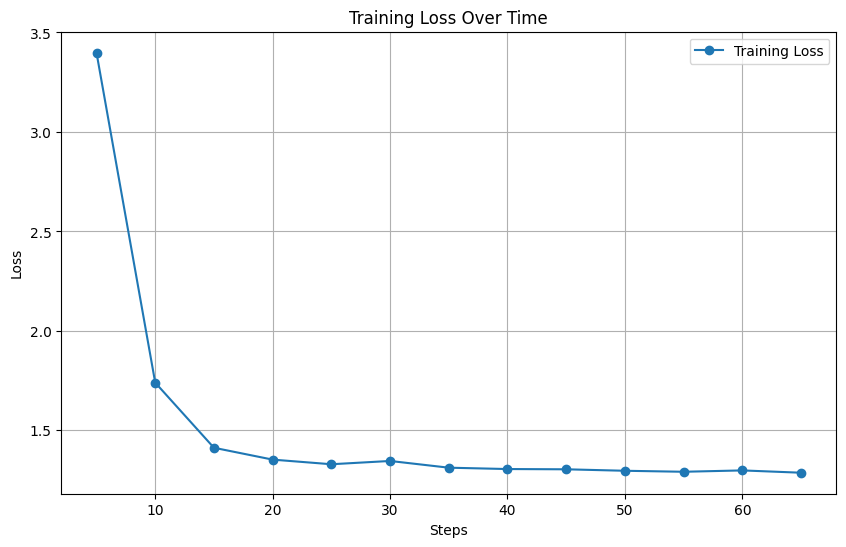

In [ ]:
from transformers import TrainingArguments
from trl import SFTTrainer
import wandb

wandb.init(mode="disabled")

torch.cuda.empty_cache()
model.gradient_checkpointing_enable()  

tokenizer.pad_token = tokenizer.eos_token

training_args = TrainingArguments(
    output_dir='kaggle/',
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    learning_rate=1e-3,
    gradient_accumulation_steps=8,
    load_best_model_at_end=False,       
    evaluation_strategy="no",
    save_strategy="steps",
    save_steps=5,
    logging_steps=5,
    report_to=None,
    logging_dir='kaggle/logs',       
)

trainer = SFTTrainer(
    model=model,
    train_dataset=fixed_dataset['train'],
    peft_config=lora_config,
    dataset_text_field="text",
    args=training_args,
    tokenizer=tokenizer,
    packing=False,
    max_seq_length=1024,
    callbacks=[EarlyStoppingCallback(patience=3, min_delta=0.01)]
)

trainer.train()
plot_losses()

Con il blocco sottostante ricaviamo l'ultimo checkpoint salvato in fase di addestramento e carichiamo il modello e il tokenizer per poi effettuare la fase di validazione e di test

In [13]:
import os
from transformers import AutoModelForCausalLM, AutoTokenizer

checkpoint_dir = 'kaggle/'

checkpoints = [os.path.join(checkpoint_dir, d) for d in os.listdir(checkpoint_dir) if d.startswith('checkpoint-')]

checkpoints = sorted(checkpoints, key=lambda x: int(x.split('-')[-1]))

last_checkpoint = checkpoints[-1]
print(f"Ultimo checkpoint trovato: {last_checkpoint}")

model = AutoModelForCausalLM.from_pretrained(last_checkpoint)
tokenizer = AutoTokenizer.from_pretrained(last_checkpoint)


Ultimo checkpoint trovato: kaggle/checkpoint-65


## Funzione ask e descrizione dei parametri impiegati per il suo utilizzo 

Definiamo la funzione ask utile per interagire con il modello in modo tale da poter porre delle domande tramite prompt e ricevere una risposta, in questo caso, contenente la classificazione del tweet.

1. Come prima operazione ricaviamo i token tramite il tokenizer.

2. Successivamente definiamo una GenerationConfig dove impostiamo do_sample e max_new_token.

    Per quanto riguarda do_sample, questo è stato posto a False, il che significa che il modello non effettuerà alcun campionamento sulla distribuzione di probabilità prodotta per la scelta del token successivo. Questo implica che il modello sceglierà sempre la parola con la probabilità più alta rendendo la risposta più deterministica e meno creativa. Abbiamo preso questa scelta poiché il nostro interesse è che il modello classifichi sempre allo stesso modo un tweet fornito più volte, il che è reso più probabile tramite il non utilizzo del campionamento.

    Per quanto riguarda max_new_tokens, questo indica il numero massimo di token che verranno prodotti dal modello. In caso di risposta più lunga questa verrà troncata. E' quindi importante che il suo valore venga scelto con precisione in modo da garantire un corretto funzionamento e una corretta classificazione.

3. Definita la configurazione generiamo la risposta tramite model.generate() al quale forniamo l'input, la maschera di attenzione e la configurazione prima descritta. La maschera di attenzione, in particolare, serve per guidare il modello su quali token prendere in considerazione e quali no. Questo meccanismo serve anche per gestire la presenza di padding nella sequenza di input.

4. Ottenuta la risposta, tramite tokenizer.batch_decode convertiamo la risposta in un formato leggibile, ovvero passiamo da una lista di id ad una lista di parole. In particolare quello che contiene response prima della decodifica è una lista di id che corrispondono ad indici della matrice di embedding, quindi quello che viene restituito è l'id degli embedding che sono stati generati dal modello.

5. Nelle righe di codice successive alla generazione della risposta e alla decodifica, ci concentriamo sull'estrazione della predizione del modello dalla risposta generata. Avendo dato direttive chiare su come classificare i tweet, quello che facciamo consiste nel cercare all'interno della risposta, tramite un'espressione regolare, la presenza di anger, joy, optimism e sadness. La funzione restituirà l'emozione rilevata. Questi valori verrano poi confrontati con l'etichetta annotata nel dataset per valutare la bontà del modello. Inoltre abbiamo gestito il caso limite in cui il modello non generi nessuna delle quattro risposte, classificando quindi il tweet come "unknown"

In [ ]:
import re
from transformers import GenerationConfig

def ask(question, model, device):
    tk = tokenizer(question, return_tensors='pt')
    tk['input_ids'] = tk['input_ids'].to(device)
    tk['attention_mask'] = tk['attention_mask'].to(device)

    gen_config = GenerationConfig(
        do_sample=False,
        max_new_tokens=20,
    )

    response = model.generate(
        input_ids=tk['input_ids'],
        attention_mask=tk['attention_mask'],
        generation_config=gen_config
    )

    print(f"response {tokenizer.decode(response[0])} fine_response\n")
    answer = tokenizer.batch_decode(response[:, len(tk['input_ids'][0]):], skip_special_tokens=True)[0]
    print(answer)

    if not answer.strip():
        return response, "unknown", ""

    match = re.search(r'\b(anger|joy|optimism|sadness)\b', answer.lower())

    if match:
        label = match.group(0)
        print(f"Detected Label: {label}")
        return response, label, answer
    else:
        # Se non trova nessuna etichetta, ritorna "unknown"
        return response, "unknown", answer


## Gestione della fase di valutazione del modello 

Qui ci occupiamo di effettuare la validazione del modello. Quindi dopo aver ottenuto il dispositivo disponibile sulla macchina carichiamo il modello su di esso. A questo punto impostiamo il modello in modalità eval per garantire un corretto funzionamento e quindi disattivare il calcolo dei gradienti che causerebbero uno spreco di risorse.

Dopo aver impostato correttamente il modello, quello che facciamo è iterare l'intero dataset di validation per la costruzione del messaggio da mandare al modello. In quest'ultimo inseriamo l'instruction, necessaria per guidare il modello sul task che dovrà compiere, e il tweet, ovvero sample[\"input\"], che dovrà essere classificato.

Successivamente tramite l'utilizzo della funzione ask definita nel blocco precedente, ricaviamo la risposta del modello e quindi la sua classificazione.

In [ ]:
from tqdm import tqdm
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

instruction = "Classify the following tweet in one of the following categories: anger, joy, optimism or sadness. Respond with only one word."

results = []  

model.eval()
with torch.no_grad():
    for idx, sample in enumerate(tqdm(fixed_dataset['val'], desc='validation set')):
        messages = [
            {'role': 'system', 'content': instruction},
            {'role': 'user', 'content': sample['input']}
        ]
    
        response, label , anwser = ask(tokenizer.apply_chat_template(messages, tokenize=False), model, device)
        results.append(label)
        print(label)

validation set:   0%|          | 1/374 [00:00<03:17,  1.89it/s]

response <|begin_of_text|><|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 10 Feb 2025

Classify the following tweet in one of the following categories: anger, joy, optimism or sadness. Respond with only one word.<|eot_id|><|start_header_id|>user<|end_header_id|>

@user @user Oh, hidden revenge and anger...I rememberthe time,she rebutted you.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

I would classify the tweet as: anger. The user is expressing anger and frustration fine_response

assistant

I would classify the tweet as: anger. The user is expressing anger and frustration
Detected Label: anger
anger


validation set:   1%|          | 2/374 [00:01<03:15,  1.91it/s]

response <|begin_of_text|><|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 10 Feb 2025

Classify the following tweet in one of the following categories: anger, joy, optimism or sadness. Respond with only one word.<|eot_id|><|start_header_id|>user<|end_header_id|>

if not then #teamchristine bc all tana has done is provoke her by tweeting shady shit and trying to be a hard bitch begging for a fight<|eot_id|><|start_header_id|>assistant<|end_header_id|>

I would classify the tweet as: anger. The user is expressing anger and frustration fine_response

assistant

I would classify the tweet as: anger. The user is expressing anger and frustration
Detected Label: anger
anger


validation set:   1%|          | 3/374 [00:01<03:14,  1.91it/s]

...

response <|begin_of_text|><|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 10 Feb 2025

Classify the following tweet in one of the following categories: anger, joy, optimism or sadness. Respond with only one word.<|eot_id|><|start_header_id|>user<|end_header_id|>

Russia story will infuriate Trump today. Media otherwise would be giving him tongue bath for fall of ISIS in Mosul + al-Baghdadi death.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

I would classify the tweet as: anger. The tone is angry and critical, fine_response

assistant

I would classify the tweet as: anger. The tone is angry and critical,
Detected Label: anger
anger


validation set: 100%|█████████▉| 373/374 [03:15<00:00,  1.96it/s]

response <|begin_of_text|><|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 10 Feb 2025

Classify the following tweet in one of the following categories: anger, joy, optimism or sadness. Respond with only one word.<|eot_id|><|start_header_id|>user<|end_header_id|>

Shit getting me irritated 😠<|eot_id|><|start_header_id|>assistant<|end_header_id|>

I would classify the tweet as: anger. The user is expressing frustration and irritation fine_response

assistant

I would classify the tweet as: anger. The user is expressing frustration and irritation
Detected Label: anger
anger


validation set: 100%|██████████| 374/374 [03:15<00:00,  1.91it/s]

response <|begin_of_text|><|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 10 Feb 2025

Classify the following tweet in one of the following categories: anger, joy, optimism or sadness. Respond with only one word.<|eot_id|><|start_header_id|>user<|end_header_id|>

@user @user If this didn't make me so angry, I'd be laughing at this tweet!<|eot_id|><|start_header_id|>assistant<|end_header_id|>

I would classify the tweet as: anger. The user is expressing frustration and anger fine_response

assistant

I would classify the tweet as: anger. The user is expressing frustration and anger
Detected Label: anger
anger


## Print di debug e conversione text-to-int

Nel blocco di codice sottostante, oltre a stampare i valori predetti per verificare il corretto funzionamento del modello, effettuaiamo una conversione delle predizioni da \"anger\", \"joy\", \"optimism\", \"sadness\" a 0, 1, 2, e 3 per poter confrontare correttamente le predizioni restituite dal modello e le label annotate nel dataset.

In [ ]:
label_to_int = {
    "anger": 0,
    "joy": 1,
    "optimism": 2,
    "sadness": 3
}

val_results = [label_to_int.get(y, -1) for y in results]

print(results)
print(val_results)
print(y_val)
print(y_val_numeriche)

['anger', 'anger', 'anger', 'anger', 'anger', 'anger', 'sadness', 'sadness', 'sadness', 'anger', 'joy', 'anger', 'anger', 'sadness', 'sadness', 'anger', 'anger', 'sadness', 'sadness', 'anger', 'sadness', 'optimism', 'optimism', 'sadness', 'sadness', 'sadness', 'sadness', 'joy', 'joy', 'anger', 'anger', 'sadness', 'optimism', 'sadness', 'optimism', 'joy', 'joy', 'anger', 'optimism', 'joy', 'joy', 'sadness', 'joy', 'anger', 'joy', 'joy', 'sadness', 'sadness', 'anger', 'anger', 'joy', 'joy', 'sadness', 'sadness', 'anger', 'sadness', 'anger', 'anger', 'joy', 'joy', 'sadness', 'optimism', 'joy', 'joy', 'sadness', 'anger', 'anger', 'anger', 'sadness', 'anger', 'anger', 'anger', 'anger', 'optimism', 'joy', 'anger', 'joy', 'anger', 'joy', 'anger', 'sadness', 'optimism', 'anger', 'optimism', 'anger', 'anger', 'sadness', 'anger', 'sadness', 'sadness', 'anger', 'joy', 'joy', 'joy', 'anger', 'sadness', 'sadness', 'optimism', 'anger', 'joy', 'optimism', 'joy', 'joy', 'joy', 'sadness', 'joy', 'sadne

## Generazione e plot delle matrici di confusione

Dovendo valutare la bontà del modello, definiamo la funzione conf_matrix che ci permette di stampare a schermo la matrice di confusione utile per mostrare come vengono classificati i tweet e quindi utile per compredenre dove il modello sbaglia.

Inoltre tramite l'utilizzo della funzione f1_score di sklearn.metrics effettuiamo il calcolo della f1_score macro.

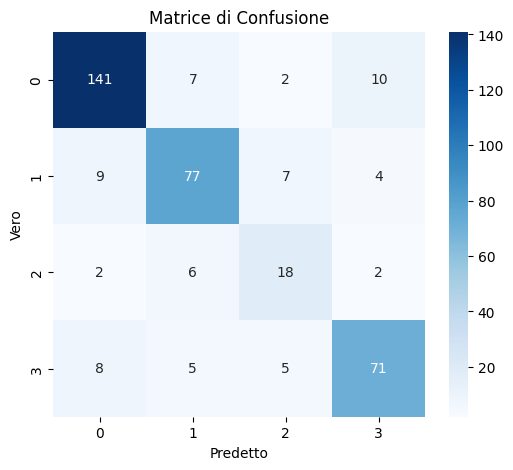

F1 Macro Score: 0.7725


In [17]:
from sklearn.metrics import f1_score
import seaborn as sns
from sklearn.metrics import confusion_matrix


def conf_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predetto")
    plt.ylabel("Vero")
    plt.title("Matrice di Confusione")
    plt.show()
    
f1_macro = f1_score(y_val_numeriche, val_results, average='macro')

conf_matrix(y_val_numeriche, val_results)

print(f'F1 Macro Score: {f1_macro:.4f}')

## Produzione delle label di test 

Una volta effettuate le fasi di training e di validation proseguiamo con la fase di test. 

In questo blocco produciamo le predizioni del modello sul dataset di test. Queste ultime vengono poi salvate in un file csv. Questo file sarà poi utilizzato per verificare tramite la piattaforma foundry l'effettivo punteggio di f1 macro ottenuto sul test. 

In [18]:
import csv
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

instruction = "Classify the following tweet in one of the following categories: anger, joy, optimism or sadness. Respond with only one word."
results_test = []

label_to_int = {
    "anger": 0,
    "joy": 1,
    "optimism": 2,
    "sadness": 3
}

model.eval()
with torch.no_grad():
    for idx, sample in enumerate(tqdm(fixed_dataset['test'], desc='test set')):
        input_text = sample['input']

        messages = [
            {'role': 'system', 'content': instruction},
            {'role': 'user', 'content': sample['input']}
        ]

        response, label, _ = ask(tokenizer.apply_chat_template(messages, tokenize=False), model, device)
        
        if label in label_to_int:
            results_test.append(label_to_int[label])

output_csv_path = f"test_tweet_label.csv"

with open(output_csv_path, mode="w", newline="", encoding="utf-8") as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["label"])
    for y in results_test:
        writer.writerow([y])


test set:   0%|          | 1/1421 [00:00<12:13,  1.94it/s]

response <|begin_of_text|><|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 10 Feb 2025

Classify the following tweet in one of the following categories: anger, joy, optimism or sadness. Respond with only one word.<|eot_id|><|start_header_id|>user<|end_header_id|>

#Deppression is real. Partners w/ #depressed people truly dont understand the depth in which they affect us. Add in #anxiety &amp;makes it worse<|eot_id|><|start_header_id|>assistant<|end_header_id|>

I would classify the tweet as: sadness. The tone is melancholic and the fine_response

assistant

I would classify the tweet as: sadness. The tone is melancholic and the
Detected Label: sadness


test set:   0%|          | 2/1421 [00:01<12:15,  1.93it/s]

response <|begin_of_text|><|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 10 Feb 2025

Classify the following tweet in one of the following categories: anger, joy, optimism or sadness. Respond with only one word.<|eot_id|><|start_header_id|>user<|end_header_id|>

@user Interesting choice of words... Are you confirming that governments fund #terrorism? Bit of an open door, but still...<|eot_id|><|start_header_id|>assistant<|end_header_id|>

I would classify the tweet as: anger. The user is expressing frustration and outrage fine_response

assistant

I would classify the tweet as: anger. The user is expressing frustration and outrage
Detected Label: anger


test set:   0%|          | 3/1421 [00:01<12:13,  1.93it/s]

...

response <|begin_of_text|><|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 10 Feb 2025

Classify the following tweet in one of the following categories: anger, joy, optimism or sadness. Respond with only one word.<|eot_id|><|start_header_id|>user<|end_header_id|>

shaft abrasions from panties merely shifted to the side\n\n#theoldsideshift #annoyance #humansoflatecapitalism<|eot_id|><|start_header_id|>assistant<|end_header_id|>

I would classify the tweet as: anger. The tone is angry and frustrated, fine_response

assistant

I would classify the tweet as: anger. The tone is angry and frustrated,
Detected Label: anger


test set: 100%|█████████▉| 1420/1421 [12:15<00:00,  1.93it/s]

response <|begin_of_text|><|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 10 Feb 2025

Classify the following tweet in one of the following categories: anger, joy, optimism or sadness. Respond with only one word.<|eot_id|><|start_header_id|>user<|end_header_id|>

All this fake outrage. Y'all need to stop 🤣<|eot_id|><|start_header_id|>assistant<|end_header_id|>

I would classify the tweet as: anger. The user is expressing frustration and disappointment fine_response

assistant

I would classify the tweet as: anger. The user is expressing frustration and disappointment
Detected Label: anger


test set: 100%|██████████| 1421/1421 [12:16<00:00,  1.93it/s]

response <|begin_of_text|><|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 10 Feb 2025

Classify the following tweet in one of the following categories: anger, joy, optimism or sadness. Respond with only one word.<|eot_id|><|start_header_id|>user<|end_header_id|>

Would be ever so grateful if you could record Garden of Forgiveness gentleman @user @user #amazing<|eot_id|><|start_header_id|>assistant<|end_header_id|>

I would classify the tweet as: joy. The user is expressing gratitude and appreciation fine_response

assistant

I would classify the tweet as: joy. The user is expressing gratitude and appreciation
Detected Label: joy
